Advitiya Apurv: 24EE10029
Afrin Munshi: 24EE10030

In [2155]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import math
from collections import Counter


In [2156]:
data=pd.read_csv("car.data",header=None)
data=data.to_numpy()
print(data)
ret="["

[['vhigh' 'vhigh' '2' ... 'small' 'low' 'unacc']
 ['vhigh' 'vhigh' '2' ... 'small' 'med' 'unacc']
 ['vhigh' 'vhigh' '2' ... 'small' 'high' 'unacc']
 ...
 ['low' 'low' '5more' ... 'big' 'low' 'unacc']
 ['low' 'low' '5more' ... 'big' 'med' 'good']
 ['low' 'low' '5more' ... 'big' 'high' 'vgood']]


In [2157]:
dic = {}
head=[]
with open('car.c45-names', 'r') as file:
    lines = file.readlines()


    dic['class'] = [v.strip() for v in lines[4].split(',')] #


    for line in lines:
        if ':' in line:
            name, vals = line.split(':')
            head.append(name.strip())
            dic[name.strip()] = [v.strip().rstrip('.') for v in vals.split(',')]

print(dic)
head.append('class')
print(head)


{'class': ['unacc', 'acc', 'good', 'vgood'], 'buying': ['vhigh', 'high', 'med', 'low'], 'maint': ['vhigh', 'high', 'med', 'low'], 'doors': ['2', '3', '4', '5more'], 'persons': ['2', '4', 'more'], 'lug_boot': ['small', 'med', 'big'], 'safety': ['low', 'med', 'high']}
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


In [2158]:
def settings(metric, depth, impurity, trseg,valseg,noise):
  D={
      "Metric":metric
      ,"Depth":depth
      ,"Impurity":impurity
      ,"Train_Seg":trseg
      ,"Val_Seg":valseg
      ,"Noise":noise
  }
  return D



In [2159]:
train=[]
valid=[]
test=[]
def fill(train,valid,test,data,trper,valper,rep=False):
  temp=data.copy()
  trl=int(trper*len(data)/100)
  vall=int(valper*len(data)/100)
  tel=len(data)-trl-vall

  if rep:
    for i in range(trl):
      train.append(random.choice(temp))
    for i in range(vall):
      valid.append(random.choice(temp))
    for i in range(tel):
      test.append(random.choice(temp))
  else:
    for i in range(len(temp)):
      r=random.randint(0,len(temp)-1)
      t=temp[r]
      temp[r]=temp[i]
      temp[i]=t
    for i in range(trl):
      train.append(temp[i])
    for i in range(vall):
      valid.append(temp[trl+i])
    for i in range(tel):
      test.append(temp[trl+vall+i])




In [2160]:
def noisy(train,head, dic,noise):
  ln=int(len(data)*len(data[0])*noise/100)
  for i in range(ln):
    r=random.randint(0,len(train)-1)
    c=random.randint(0,len(train[0])-1)
    h=head[c]
    train[r][c]=random.choice(dic[h])



In [2161]:
def entropy(y):
    total = len(y)
    counts = Counter(y)
    H = 0
    for c in counts:
        p = counts[c] / total
        H -= p * math.log2(p)
    return H


In [2162]:
def gini(y):
    total = len(y)
    counts = Counter(y)
    G = 1
    for c in counts:
        p = counts[c] / total
        G -= p**2
    return G

In [2163]:
def impurity(y, metric):
    if metric == "Entropy":
        return entropy(y)
    elif metric == "Gini":
        return gini(y)

In [2164]:
def information_gain(data, col, metric):
    y = data[:, -1]
    base_imp = impurity(y, metric)
    values = np.unique(data[:, col])

    weighted_imp = 0
    for v in values:
        subset = data[data[:, col] == v]
        weight = len(subset) / len(data)
        weighted_imp += weight * impurity(subset[:, -1], metric)

    return base_imp - weighted_imp


In [2165]:
class Node:
    def __init__(self, attribute=None, label=None):
        self.attribute = attribute
        self.children = {}
        self.label = label

In [2166]:
def build_tree(data, head, metric, depth, max_depth, max_impurity):

    y = data[:, -1]

    if len(set(y)) == 1:
        return Node(label=y[0])


    if len(head) == 0:
        return Node(label=Counter(y).most_common(1)[0][0])

    if depth == max_depth:
        return Node(label=Counter(y).most_common(1)[0][0])


    if impurity(y, metric) <= max_impurity:
        return Node(label=Counter(y).most_common(1)[0][0])


    gains = []
    for i in range(len(head)):
        gains.append(information_gain(data, i, metric))

    best_attr = np.argmax(gains)

    node = Node(attribute=head[best_attr])

    values = np.unique(data[:, best_attr])

    for v in values:
        subset = data[data[:, best_attr] == v]

        if len(subset) == 0:
            node.children[v] = Node(label=Counter(y).most_common(1)[0][0])
        else:
            new_head = head[:best_attr] + head[best_attr+1:]
            reduced_subset = np.delete(subset, best_attr, axis=1)

            node.children[v] = build_tree(
                reduced_subset,
                new_head,
                metric,
                depth + 1,
                max_depth,
                max_impurity
            )

    return node

In [2167]:
def predict_one(node, sample, head):

    if node.label is not None:
        return node.label

    attr_index = head.index(node.attribute)
    value = sample[attr_index]

    if value in node.children:
        return predict_one(node.children[value], sample, head)
    else:
        return None

In [2168]:
def accuracy(tree, dataset, head):
    correct = 0
    for row in dataset:
        pred = predict_one(tree, row, head)
        if pred == row[-1]:
            correct += 1
    return correct / len(dataset)

In [2169]:
S0 = settings("Entropy", depth=1e22, impurity=0, trseg=80, valseg=10, noise=0)
fill(train,valid,test,data,S0["Train_Seg"],S0["Val_Seg"],rep=False)
noisy(train,head,dic,S0["Noise"])
train_np = np.array(train)
valid_np = np.array(valid)
test_np  = np.array(test)

tree = build_tree(
    train_np,
    head[:-1],
    S0["Metric"],
    depth=0,
    max_depth=S0["Depth"],
    max_impurity=S0["Impurity"]
)

print("Train Accuracy:", accuracy(tree, train_np, head))
print("Validation Accuracy:", accuracy(tree, valid_np, head))
print("Test Accuracy:", accuracy(tree, test_np, head))

Train Accuracy: 1.0
Validation Accuracy: 0.9941860465116279
Test Accuracy: 0.9712643678160919


In [2170]:
def printTree(node,s):
  global ret

  if node.label is not None:
      ret=ret+s[:-5]+"]=> ("+node.label+""")
OR ["""
      return

  for v in node.children:
        ss="("+node.attribute
        ss=ss+"="+v+") AND "
        printTree(node.children[v],s+ss)
printTree(tree,"")
print(ret[:-5])

[(safety=high) AND (persons=2)]=> (unacc)
OR [(safety=high) AND (persons=4) AND (buying=high) AND (maint=high)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=high) AND (maint=low)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=high) AND (maint=med)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=high) AND (maint=vhigh)]=> (unacc)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (maint=high) AND (lug_boot=big)]=> (vgood)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (maint=high) AND (lug_boot=small)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (maint=low) AND (lug_boot=big)]=> (vgood)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (maint=low) AND (lug_boot=small)]=> (good)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (maint=med) AND (doors=2)]=> (good)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (maint=med) AND (doors=4)]=> (good)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (maint=med) AND (

In [2171]:
node_impurities = []

def build_tree_record(data, head, metric):
    y = data[:, -1]

    current_imp = impurity(y, metric)
    node_impurities.append(current_imp)

    if len(set(y)) == 1:
        return Node(label=y[0])

    if len(head) == 0:
        return Node(label=Counter(y).most_common(1)[0][0])

    gains = [information_gain(data, i, metric) for i in range(len(head))]
    best_attr = np.argmax(gains)

    node = Node(attribute=head[best_attr])
    values = np.unique(data[:, best_attr])

    for v in values:
        subset = data[data[:, best_attr] == v]

        if len(subset) == 0:
            node.children[v] = Node(label=Counter(y).most_common(1)[0][0])
        else:
            new_head = head[:best_attr] + head[best_attr+1:]
            reduced_subset = np.delete(subset, best_attr, axis=1)
            node.children[v] = build_tree_record(
                reduced_subset,
                new_head,
                metric
            )
    return node

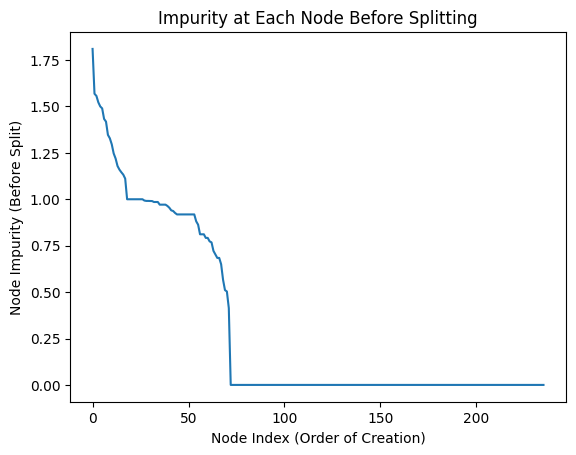

In [2172]:
node_impurities = []
tree = build_tree_record(train_np, head[:-1], "Entropy")
#node_impurities.sort()
#node_impurities.reverse()
plt.figure()
plt.plot(node_impurities)
plt.xlabel("Node Index (Order of Creation)")
plt.ylabel("Node Impurity (Before Split)")
plt.title("Impurity at Each Node Before Splitting")
plt.show()

In [2173]:
train=[]
valid=[]
test=[]
ret="["
S1=settings("Entropy", depth=1e22, impurity=0, trseg=60, valseg=20, noise=0)
fill(train,valid,test,data,S1["Train_Seg"],S1["Val_Seg"],rep=False)
noisy(train,head,dic,S1["Noise"])
train_np = np.array(train)
valid_np = np.array(valid)
test_np  = np.array(test)

tree = build_tree(
    train_np,
    head[:-1],
    S1["Metric"],
    depth=0,
    max_depth=S1["Depth"],
    max_impurity=S1["Impurity"]
)

print("Train Accuracy:", accuracy(tree, train_np, head))
print("Validation Accuracy:", accuracy(tree, valid_np, head))
print("Test Accuracy:", accuracy(tree, test_np, head))

Train Accuracy: 1.0
Validation Accuracy: 0.9333333333333333
Test Accuracy: 0.9279538904899135


In [2174]:
def printTree(node,s):
  global ret

  if node.label is not None:
      ret=ret+s[:-5]+"]=> ("+node.label+""")
OR ["""
      return

  for v in node.children:
        ss="("+node.attribute
        ss=ss+"="+v+") AND "
        printTree(node.children[v],s+ss)
printTree(tree,"")
print(ret[:-5])

[(safety=high) AND (persons=2)]=> (unacc)
OR [(safety=high) AND (persons=4) AND (buying=high) AND (maint=high)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=high) AND (maint=low)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=high) AND (maint=med)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=high) AND (maint=vhigh)]=> (unacc)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (lug_boot=big)]=> (vgood)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (lug_boot=med) AND (maint=low)]=> (vgood)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (lug_boot=med) AND (maint=vhigh)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (lug_boot=small) AND (maint=low)]=> (good)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (lug_boot=small) AND (maint=med)]=> (good)
OR [(safety=high) AND (persons=4) AND (buying=low) AND (lug_boot=small) AND (maint=vhigh)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=med) AND (maint=high)]=> (acc

In [2175]:
train=[]
valid=[]
test=[]
ret="["
S2=settings("Entropy", depth=1e22, impurity=0, trseg=80, valseg=10, noise=10)
fill(train,valid,test,data,S2["Train_Seg"],S2["Val_Seg"],rep=False)
noisy(train,head,dic,S2["Noise"])
train_np = np.array(train)
valid_np = np.array(valid)
test_np  = np.array(test)

tree = build_tree(
    train_np,
    head[:-1],
    S2["Metric"],
    depth=0,
    max_depth=S2["Depth"],
    max_impurity=S2["Impurity"]
)

print("Train Accuracy:", accuracy(tree, train_np, head))
print("Validation Accuracy:", accuracy(tree, valid_np, head))
print("Test Accuracy:", accuracy(tree, test_np, head))

Train Accuracy: 0.9218523878437048
Validation Accuracy: 0.7209302325581395
Test Accuracy: 0.764367816091954


In [2176]:
def printTree(node,s):
  global ret

  if node.label is not None:
      ret=ret+s[:-5]+"]=> ("+node.label+""")
OR ["""
      return

  for v in node.children:
        ss="("+node.attribute
        ss=ss+"="+v+") AND "
        printTree(node.children[v],s+ss)
printTree(tree,"")
print(ret[:-5])

[(safety=high) AND (persons=2) AND (doors=2) AND (maint=high) AND (lug_boot=big) AND (buying=high)]=> (unacc)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=high) AND (lug_boot=big) AND (buying=med)]=> (vgood)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=high) AND (lug_boot=big) AND (buying=vhigh)]=> (acc)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=high) AND (lug_boot=med)]=> (unacc)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=high) AND (lug_boot=small)]=> (unacc)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=low) AND (lug_boot=big)]=> (unacc)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=low) AND (lug_boot=med) AND (buying=low)]=> (unacc)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=low) AND (lug_boot=med) AND (buying=vhigh)]=> (acc)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=low) AND (lug_boot=small)]=> (unacc)
OR [(safety=high) AND (persons=2) AND (doors=2) AND (maint=med

In [2177]:
train=[]
valid=[]
test=[]
ret="["
S3=settings("Entropy", depth=1e22, impurity=0, trseg=60, valseg=20, noise=10)
fill(train,valid,test,data,S3["Train_Seg"],S3["Val_Seg"],rep=False)
noisy(train,head,dic,S3["Noise"])
train_np = np.array(train)
valid_np = np.array(valid)
test_np  = np.array(test)

tree = build_tree(
    train_np,
    head[:-1],
    S3["Metric"],
    depth=0,
    max_depth=S3["Depth"],
    max_impurity=S3["Impurity"]
)

print("Train Accuracy:", accuracy(tree, train_np, head))
print("Validation Accuracy:", accuracy(tree, valid_np, head))
print("Test Accuracy:", accuracy(tree, test_np, head))

Train Accuracy: 0.9247104247104247
Validation Accuracy: 0.6811594202898551
Test Accuracy: 0.6829971181556196


In [2178]:
def printTree(node,s):
  global ret

  if node.label is not None:
      ret=ret+s[:-5]+"]=> ("+node.label+""")
OR ["""
      return

  for v in node.children:
        ss="("+node.attribute
        ss=ss+"="+v+") AND "
        printTree(node.children[v],s+ss)
printTree(tree,"")
print(ret[:-5])

[(persons=2) AND (doors=2) AND (maint=high) AND (safety=high)]=> (unacc)
OR [(persons=2) AND (doors=2) AND (maint=high) AND (safety=low) AND (lug_boot=big)]=> (unacc)
OR [(persons=2) AND (doors=2) AND (maint=high) AND (safety=low) AND (lug_boot=med) AND (buying=high)]=> (unacc)
OR [(persons=2) AND (doors=2) AND (maint=high) AND (safety=low) AND (lug_boot=med) AND (buying=vhigh)]=> (vgood)
OR [(persons=2) AND (doors=2) AND (maint=high) AND (safety=low) AND (lug_boot=small)]=> (unacc)
OR [(persons=2) AND (doors=2) AND (maint=high) AND (safety=med)]=> (unacc)
OR [(persons=2) AND (doors=2) AND (maint=low) AND (buying=high) AND (lug_boot=big)]=> (unacc)
OR [(persons=2) AND (doors=2) AND (maint=low) AND (buying=high) AND (lug_boot=med) AND (safety=low)]=> (unacc)
OR [(persons=2) AND (doors=2) AND (maint=low) AND (buying=high) AND (lug_boot=med) AND (safety=med)]=> (acc)
OR [(persons=2) AND (doors=2) AND (maint=low) AND (buying=high) AND (lug_boot=small)]=> (unacc)
OR [(persons=2) AND (doors=

In [2179]:
train=[]
valid=[]
test=[]
ret="["
S4=settings("Entropy", depth=3, impurity=0.25, trseg=80, valseg=10, noise=0)
fill(train,valid,test,data,S4["Train_Seg"],S4["Val_Seg"],rep=False)
noisy(train,head,dic,S4["Noise"])
train_np = np.array(train)
valid_np = np.array(valid)
test_np  = np.array(test)

tree = build_tree(
    train_np,
    head[:-1],
    S4["Metric"],
    depth=0,
    max_depth=S4["Depth"],
    max_impurity=S4["Impurity"]
)

print("Train Accuracy:", accuracy(tree, train_np, head))
print("Validation Accuracy:", accuracy(tree, valid_np, head))
print("Test Accuracy:", accuracy(tree, test_np, head))

Train Accuracy: 0.8422575976845152
Validation Accuracy: 0.8488372093023255
Test Accuracy: 0.7183908045977011


In [2180]:
def printTree(node,s):
  global ret

  if node.label is not None:
      ret=ret+s[:-5]+"]=> ("+node.label+""")
OR ["""
      return

  for v in node.children:
        ss="("+node.attribute
        ss=ss+"="+v+") AND "
        printTree(node.children[v],s+ss)
printTree(tree,"")
print(ret[:-5])

[(safety=high) AND (persons=2)]=> (unacc)
OR [(safety=high) AND (persons=4) AND (buying=high)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=low)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=med)]=> (acc)
OR [(safety=high) AND (persons=4) AND (buying=vhigh)]=> (unacc)
OR [(safety=high) AND (persons=more) AND (buying=high)]=> (acc)
OR [(safety=high) AND (persons=more) AND (buying=low)]=> (acc)
OR [(safety=high) AND (persons=more) AND (buying=med)]=> (acc)
OR [(safety=high) AND (persons=more) AND (buying=vhigh)]=> (unacc)
OR [(safety=low)]=> (unacc)
OR [(safety=med) AND (persons=2)]=> (unacc)
OR [(safety=med) AND (persons=4) AND (buying=high)]=> (unacc)
OR [(safety=med) AND (persons=4) AND (buying=low)]=> (acc)
OR [(safety=med) AND (persons=4) AND (buying=med)]=> (acc)
OR [(safety=med) AND (persons=4) AND (buying=vhigh)]=> (unacc)
OR [(safety=med) AND (persons=more) AND (buying=high)]=> (unacc)
OR [(safety=med) AND (persons=more) AND (buying=low)]=> (acc)
OR [(safety=me

In [2181]:
train=[]
valid=[]
test=[]
ret="["
S5=settings("Gini", depth=1e22, impurity=0, trseg=80, valseg=10, noise=0)
fill(train,valid,test,data,S5["Train_Seg"],S5["Val_Seg"],rep=False)
noisy(train,head,dic,S5["Noise"])
train_np = np.array(train)
valid_np = np.array(valid)
test_np  = np.array(test)

tree = build_tree(
    train_np,
    head[:-1],
    S5["Metric"],
    depth=0,
    max_depth=S5["Depth"],
    max_impurity=S5["Impurity"]
)

print("Train Accuracy:", accuracy(tree, train_np, head))
print("Validation Accuracy:", accuracy(tree, valid_np, head))
print("Test Accuracy:", accuracy(tree, test_np, head))

Train Accuracy: 1.0
Validation Accuracy: 0.9476744186046512
Test Accuracy: 0.9770114942528736


In [2182]:
def printTree(node,s):
  global ret

  if node.label is not None:
      ret=ret+s[:-5]+"]=> ("+node.label+""")
OR ["""
      return

  for v in node.children:
        ss="("+node.attribute
        ss=ss+"="+v+") AND "
        printTree(node.children[v],s+ss)
printTree(tree,"")
print(ret[:-5])

[(safety=high) AND (persons=2)]=> (unacc)
OR [(safety=high) AND (persons=4) AND (maint=high) AND (buying=high)]=> (acc)
OR [(safety=high) AND (persons=4) AND (maint=high) AND (buying=low) AND (lug_boot=big)]=> (vgood)
OR [(safety=high) AND (persons=4) AND (maint=high) AND (buying=low) AND (lug_boot=med) AND (doors=3)]=> (acc)
OR [(safety=high) AND (persons=4) AND (maint=high) AND (buying=low) AND (lug_boot=med) AND (doors=5more)]=> (vgood)
OR [(safety=high) AND (persons=4) AND (maint=high) AND (buying=low) AND (lug_boot=small)]=> (acc)
OR [(safety=high) AND (persons=4) AND (maint=high) AND (buying=med)]=> (acc)
OR [(safety=high) AND (persons=4) AND (maint=high) AND (buying=vhigh)]=> (unacc)
OR [(safety=high) AND (persons=4) AND (maint=low) AND (buying=high)]=> (acc)
OR [(safety=high) AND (persons=4) AND (maint=low) AND (buying=low) AND (lug_boot=big)]=> (vgood)
OR [(safety=high) AND (persons=4) AND (maint=low) AND (buying=low) AND (lug_boot=med)]=> (good)
OR [(safety=high) AND (persons

In [2183]:
train=[]
valid=[]
test=[]
acctr=[]
accv=[]
acctes=[]
S0 = settings("Entropy", depth=15, impurity=0, trseg=80, valseg=10, noise=0)
fill(train,valid,test,data,S0["Train_Seg"],S0["Val_Seg"],rep=False)
for i in range(1,S0["Depth"]):
  tree = build_tree(
    train_np,
    head[:-1],
    S4["Metric"],
    depth=0,
    max_depth=i,
    max_impurity=S0["Impurity"]
  )
  acctr.append(accuracy(tree, train_np, head))
  accv.append(accuracy(tree, valid_np, head))
  acctes.append(accuracy(tree, test_np, head))
  """print("Train Accuracy:", accuracy(tree, train_np, head))
  print("Validation Accuracy:", accuracy(tree, valid_np, head))
  print("Test Accuracy:", accuracy(tree, test_np, head))"""


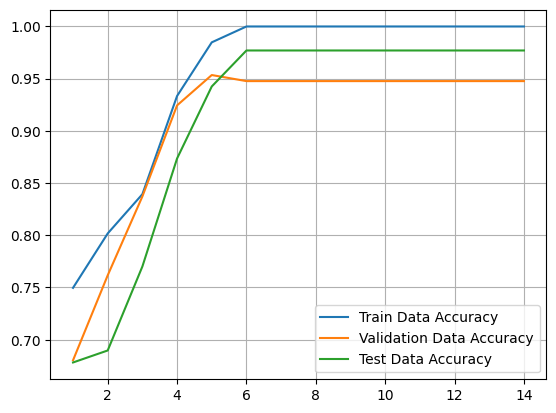

In [2184]:
x=list(range(1,15))
plt.plot(x,acctr,label="Train Data Accuracy")
plt.plot(x,accv,label="Validation Data Accuracy")
plt.plot(x,acctes,label="Test Data Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Random forest working starts here

In [2185]:
numsTree=100
fBS=4
dBS=80
rfs=[]
accr=0

In [2186]:
def build_treerf(data, head, metric,fbs, depth, max_depth, max_impurity):

    y = data[:, -1]

    if len(set(y)) == 1:
        return Node(label=y[0])


    if len(head) == 0:
        return Node(label=Counter(y).most_common(1)[0][0])

    if depth == max_depth:
        return Node(label=Counter(y).most_common(1)[0][0])


    if impurity(y, metric) <= max_impurity:
        return Node(label=Counter(y).most_common(1)[0][0])


    gains = []
    idx=set()
    if(len(head)<fBS):
     for i in range(len(head)):
        gains.append(information_gain(data, i, metric))
    else:
     while(len(idx)<fBS):
      idx.add(random.randint(0,len(head)))
     for i in idx:
        gains.append(information_gain(data, i, metric))

    best_attr = np.argmax(gains)

    node = Node(attribute=head[best_attr])

    values = np.unique(data[:, best_attr])

    for v in values:
        subset = data[data[:, best_attr] == v]

        if len(subset) == 0:
            node.children[v] = Node(label=Counter(y).most_common(1)[0][0])
        else:
            new_head = head[:best_attr] + head[best_attr+1:]
            reduced_subset = np.delete(subset, best_attr, axis=1)

            node.children[v] = build_tree(
                reduced_subset,
                new_head,
                metric,
                depth + 1,
                max_depth,
                max_impurity
            )

    return node

In [2187]:
train=[]
outofbag=[]
valid=[]
test=[]
fill(train,valid,test,data,80,10,True)
noisy(train,head,dic,0)
np_train=np.array(train)
np_valid=np.array(valid)
np_test=np.array(test)
trrf=[]
def fillrf(trrf,outofbag,data,dbs):
  temp=data.copy()
  trl=int((dbs*len(data)/100))
  idx=[]

  for i in range(trl):
    idx.append(random.randint(0,len(temp)-1))
    trrf.append(temp[idx[i]])
  idx=set(idx)
  idx=list(idx)
  idx.sort()
  for i in range(len(idx)-1,-1,-1):
    np.delete(temp, idx[i], axis=0)
  return temp





In [2188]:
for i in range(numsTree):
  trrf=[]
  outofbag=fillrf(trrf,outofbag,np_train,dBS)
  np_trrf=np.array(trrf)
  np_outofbag=np.array(outofbag)


  tree = build_treerf(
    np_trrf,
    head[:-1],
    "Entropy",
    fBS,
    depth=0,
    max_depth=10000,
    max_impurity=0
  )
  rfs.append(tree)
  acc=accuracy(tree, np_outofbag, head)
  #print(acc)
  accr+=acc



In [2189]:
print("Average Out of Bag Accuracy=",accr/numsTree)

Average Out of Bag Accuracy= 0.9571997105643996


In [2190]:
def AccRF(data,rfs):
  accur=0;
  for row in data:
    dic={}
    for tree in rfs:
      pred=predict_one(tree,row,head)
      if pred in dic:
        dic[pred]+=1
      else:
        dic[pred]=1
    max=0
    label=""
    for key in dic:
      if dic[key]>max:
        max=dic[key]
        label=key
    if label==row[-1]:
      accur+=1
  return accur/len(data)


In [2191]:
print("Validation Accuracy Random Forest=",AccRF(np_valid,rfs))
print("Test Accuracy Random Forest=",AccRF(np_test,rfs))


Validation Accuracy Random Forest= 0.936046511627907
Test Accuracy Random Forest= 0.896551724137931


In [2192]:
tree = build_tree(
    np_train,
    head[:-1],
    "Entropy",
    depth=0,
    max_depth=100,
    max_impurity=0
)

print("Validation Accuracy Decision Tree=", accuracy(tree, np_valid, head))
print("Test Accuracy Decision Tree=", accuracy(tree, np_test, head))

Validation Accuracy Decision Tree= 0.9418604651162791
Test Accuracy Decision Tree= 0.896551724137931


In [2193]:
dict={}
for tree in rfs:
  root=tree.attribute
  if(root in dict):
    dict[root]+=1
  else:
    dict[root]=1
print(dict)

{'persons': 87, 'doors': 11, 'buying': 2}
